# Dataset EDA — Simulation Inverse Model
Full exploratory analysis: distributions, correlations, identifiability, and KPI coverage.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CHANGE THIS ──────────────────────────────
CSV_PATH = 'dataset09.1.csv'
# ─────────────────────────────────────────────

PARAMS = ['RSSI_INFLECTION_POINT', 'PATH_LOSS_EXPONENT', 'AWGN_SIGMA']
KPIS   = ['mean_rssi_dbm', 'std_rssi_dbm', 'min_rssi_dbm',
          'loss_rate_pct', 'throughput_pkt_s',
          'mean_delay_s', 'std_delay_s',
          'std_loss_rate', 'per_node_min_prr']

df = pd.read_csv(CSV_PATH)
# Fill RSSI NaNs
df['mean_rssi_dbm'] = df['mean_rssi_dbm'].fillna(-100.0)
df['std_rssi_dbm']  = df['std_rssi_dbm'].fillna(0.0)
df['min_rssi_dbm']  = df['min_rssi_dbm'].fillna(-100.0)

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'NaN remaining: {df[KPIS+PARAMS].isnull().sum().sum()}')
display(df[KPIS + PARAMS].describe().round(3))

Dataset: 8940 rows × 15 columns
NaN remaining: 0


,mean_rssi_dbm,std_rssi_dbm,min_rssi_dbm,loss_rate_pct,throughput_pkt_s,mean_delay_s,std_delay_s,std_loss_rate,per_node_min_prr,RSSI_INFLECTION_POINT,PATH_LOSS_EXPONENT,AWGN_SIGMA
count,8940.000,8940.000,8940.000,8940.000,8940.000,8940.000,8940.000,8940.000,8940.000,8940.000,8940.000,8940.000
mean,-57.752,7.799,-83.676,33.163,80.241,1.200,0.534,5.533,0.586,-75.017,2.998,7.693
std,20.384,4.265,17.098,39.236,47.104,1.382,0.516,6.081,0.387,27.072,1.216,4.129
min,-100.000,0.000,-100.000,0.580,0.000,0.000,0.000,0.000,0.000,-120.000,1.000,1.000
25%,-73.220,4.568,-100.000,3.240,30.112,0.439,0.249,1.323,0.126,-100.000,2.000,4.000
50%,-56.045,7.902,-88.000,7.310,111.300,0.491,0.304,3.763,0.807,-75.000,3.000,7.500
75%,-41.348,11.208,-71.000,74.912,116.170,1.351,0.701,7.553,0.920,-50.000,4.000,11.000
max,-24.470,23.096,-36.000,100.000,119.450,9.471,4.606,44.741,0.992,-30.000,5.000,23.000


## 1. Parameter Distributions
Are parameters uniformly sampled or skewed?

RSSI_INFLECTION_POINT: 23 unique values → [np.float64(-120.0), np.float64(-115.0), np.float64(-110.0), np.float64(-105.0), np.float64(-100.0), np.float64(-95.0), np.float64(-90.0), np.float64(-85.0), np.float64(-83.0), np.float64(-80.0), np.float64(-78.0), np.float64(-75.0), np.float64(-73.0), np.float64(-70.0), np.float64(-68.0), np.float64(-65.0), np.float64(-60.0), np.float64(-55.0), np.float64(-50.0), np.float64(-45.0), np.float64(-40.0), np.float64(-35.0), np.float64(-30.0)]
PATH_LOSS_EXPONENT: 17 unique values → [np.float64(1.0), np.float64(1.25), np.float64(1.5), np.float64(1.75), np.float64(2.0), np.float64(2.25), np.float64(2.5), np.float64(2.75), np.float64(3.0), np.float64(3.25), np.float64(3.5), np.float64(3.75), np.float64(4.0), np.float64(4.25), np.float64(4.5), np.float64(4.75), np.float64(5.0)]
AWGN_SIGMA: 32 unique values → [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64

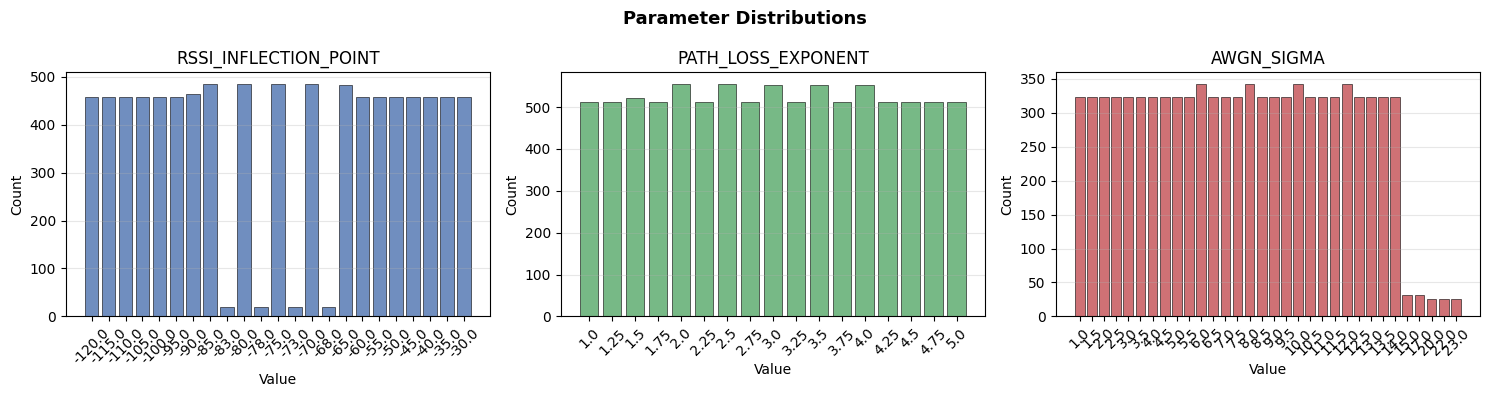

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Parameter Distributions', fontsize=13, fontweight='bold')
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, param, color in zip(axes, PARAMS, colors):
    vals = sorted(df[param].unique())
    counts = [df[df[param]==v].shape[0] for v in vals]
    ax.bar([str(v) for v in vals], counts, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(param)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    print(f'{param}: {len(vals)} unique values → {vals}')

plt.tight_layout()
plt.savefig('eda_param_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. KPI Distributions
Are KPIs well spread or concentrated in certain ranges?

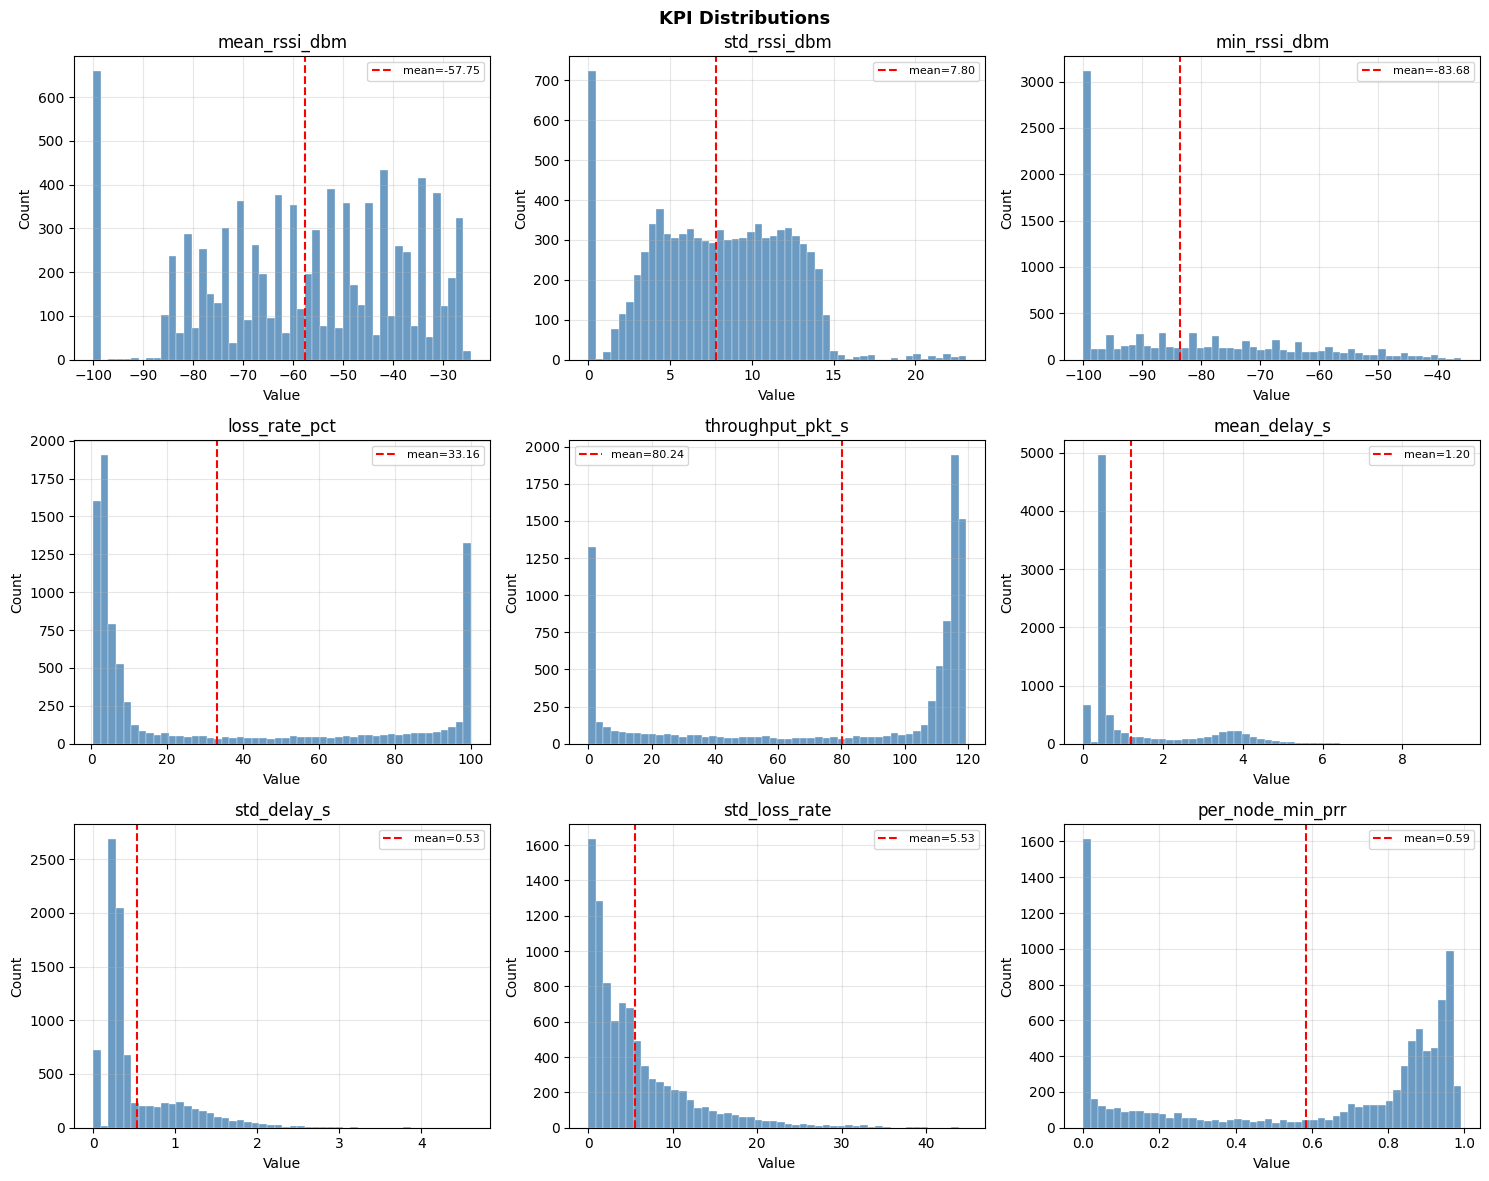

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('KPI Distributions', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, kpi in zip(axes, KPIS):
    ax.hist(df[kpi], bins=50, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(kpi)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)
    ax.axvline(df[kpi].mean(), color='red', linestyle='--', linewidth=1.5, label=f'mean={df[kpi].mean():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_kpi_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Loss Rate Coverage
Critical: does the dataset cover the full loss rate range including near-zero?

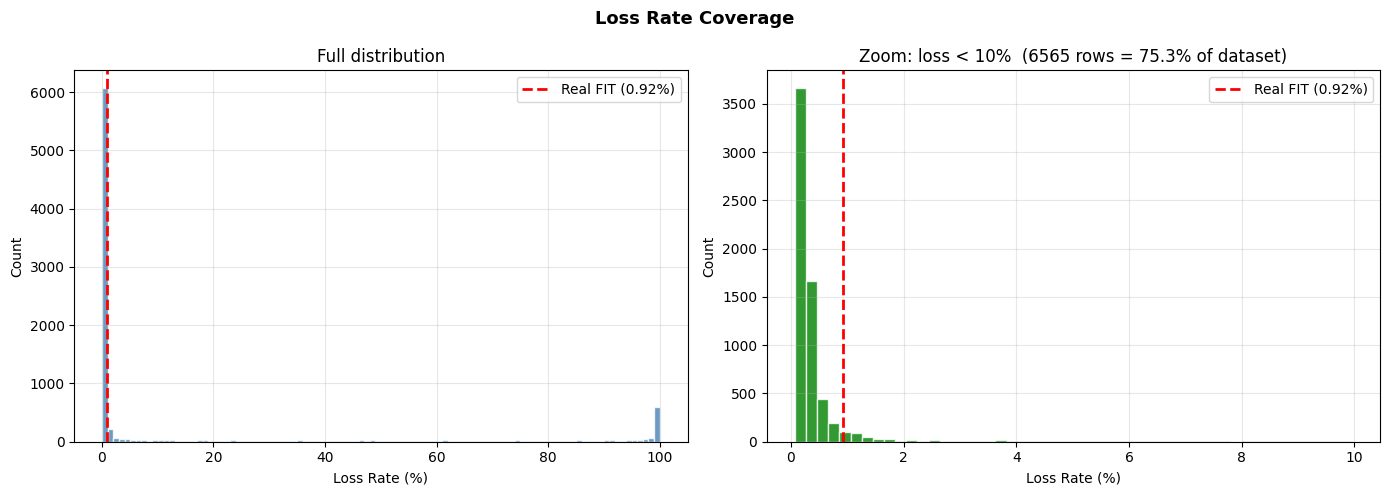

Loss rate buckets:
    0% –   1%  :  6044 rows  (69.3%)
    1% –   5%  :   379 rows  (4.3%)
    5% –  10%  :   142 rows  (1.6%)
   10% –  25%  :   282 rows  (3.2%)
   25% –  50%  :   388 rows  (4.4%)
   50% –  75%  :   352 rows  (4.0%)
   75% – 100%  :   811 rows  (9.3%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Loss Rate Coverage', fontsize=13, fontweight='bold')

# Full range histogram
axes[0].hist(df['loss_rate_pct'], bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Loss Rate (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Full distribution')
axes[0].axvline(0.92, color='red', linestyle='--', linewidth=2, label='Real FIT (0.92%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom into low loss region
low = df[df['loss_rate_pct'] < 10]
axes[1].hist(low['loss_rate_pct'], bins=50, color='green', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Loss Rate (%)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Zoom: loss < 10%  ({len(low)} rows = {len(low)/len(df)*100:.1f}% of dataset)')
axes[1].axvline(0.92, color='red', linestyle='--', linewidth=2, label='Real FIT (0.92%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_loss_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# Buckets
print('Loss rate buckets:')
buckets = [0, 1, 5, 10, 25, 50, 75, 100]
for i in range(len(buckets)-1):
    lo, hi = buckets[i], buckets[i+1]
    count = ((df['loss_rate_pct'] >= lo) & (df['loss_rate_pct'] < hi)).sum()
    print(f'  {lo:>3}% – {hi:>3}%  : {count:>5} rows  ({count/len(df)*100:.1f}%)')

## 4. Parameter → KPI Correlation Matrix
Spearman correlation — which parameters most influence which KPIs?

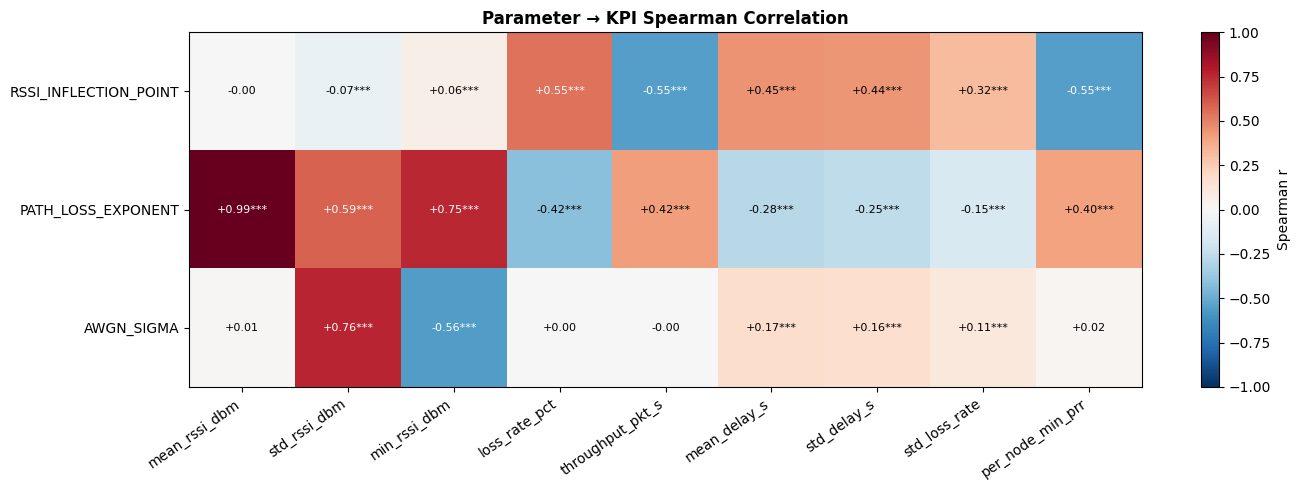

In [6]:
from scipy import stats

corr_matrix = np.zeros((len(PARAMS), len(KPIS)))
pval_matrix = np.zeros((len(PARAMS), len(KPIS)))

for i, p in enumerate(PARAMS):
    for j, k in enumerate(KPIS):
        r, pv = stats.spearmanr(df[p], df[k])
        corr_matrix[i, j] = r
        pval_matrix[i, j] = pv

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman r')

ax.set_xticks(range(len(KPIS)))
ax.set_xticklabels(KPIS, rotation=35, ha='right')
ax.set_yticks(range(len(PARAMS)))
ax.set_yticklabels(PARAMS)
ax.set_title('Parameter → KPI Spearman Correlation', fontweight='bold')

for i in range(len(PARAMS)):
    for j in range(len(KPIS)):
        stars = '***' if pval_matrix[i,j] < 0.001 else ('**' if pval_matrix[i,j] < 0.01 else ('*' if pval_matrix[i,j] < 0.05 else ''))
        ax.text(j, i, f'{corr_matrix[i,j]:+.2f}{stars}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black')

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. KPI–KPI Correlation
Are KPIs redundant with each other? High correlation = less independent information.

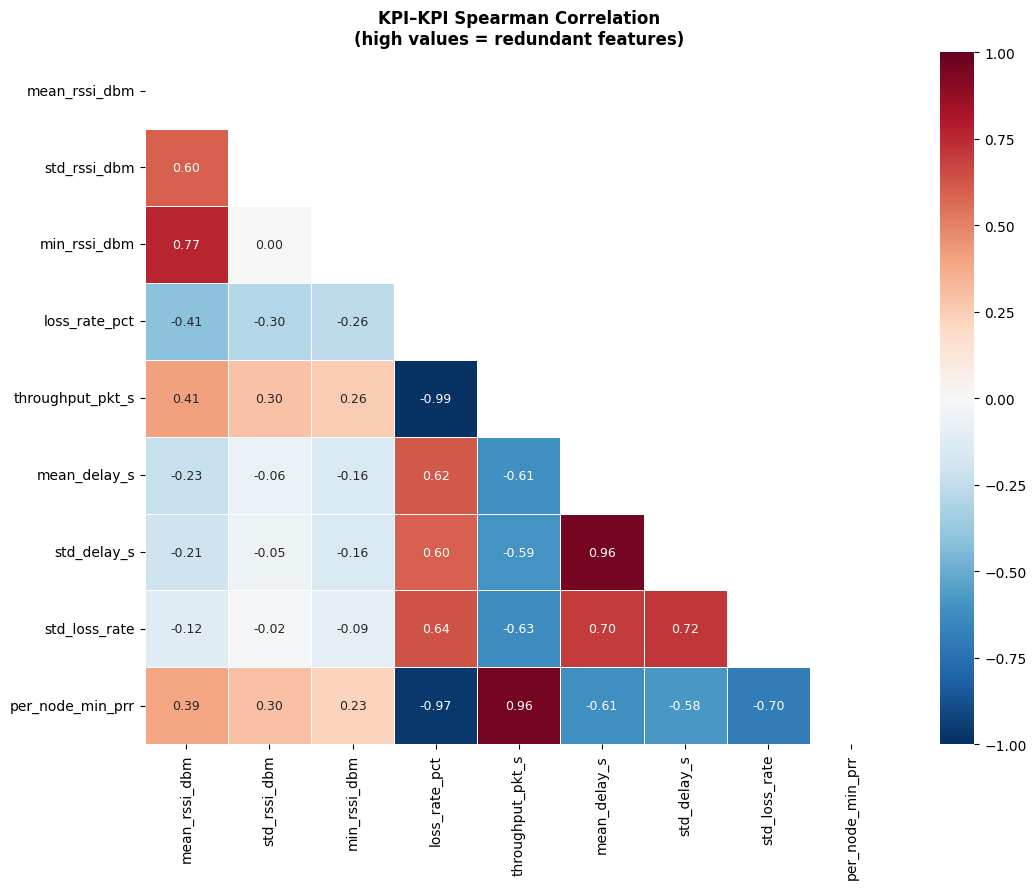

Highly correlated KPI pairs (|r| > 0.85):
  loss_rate_pct ↔ throughput_pkt_s: r=-0.988
  loss_rate_pct ↔ per_node_min_prr: r=-0.966
  throughput_pkt_s ↔ per_node_min_prr: r=0.960
  mean_delay_s ↔ std_delay_s: r=0.956


In [7]:
kpi_corr = df[KPIS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(kpi_corr, dtype=bool))
sns.heatmap(kpi_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('KPI–KPI Spearman Correlation\n(high values = redundant features)', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_kpi_corr.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs
print('Highly correlated KPI pairs (|r| > 0.85):')
found = False
for i in range(len(KPIS)):
    for j in range(i+1, len(KPIS)):
        r = kpi_corr.iloc[i, j]
        if abs(r) > 0.85:
            print(f'  {KPIS[i]} ↔ {KPIS[j]}: r={r:.3f}')
            found = True
if not found:
    print('  None found — all KPIs carry independent information ✓')

## 6. Identifiability Analysis
Key question: do similar KPI values always map to similar parameters?  
If not, the inverse model is fundamentally ambiguous.

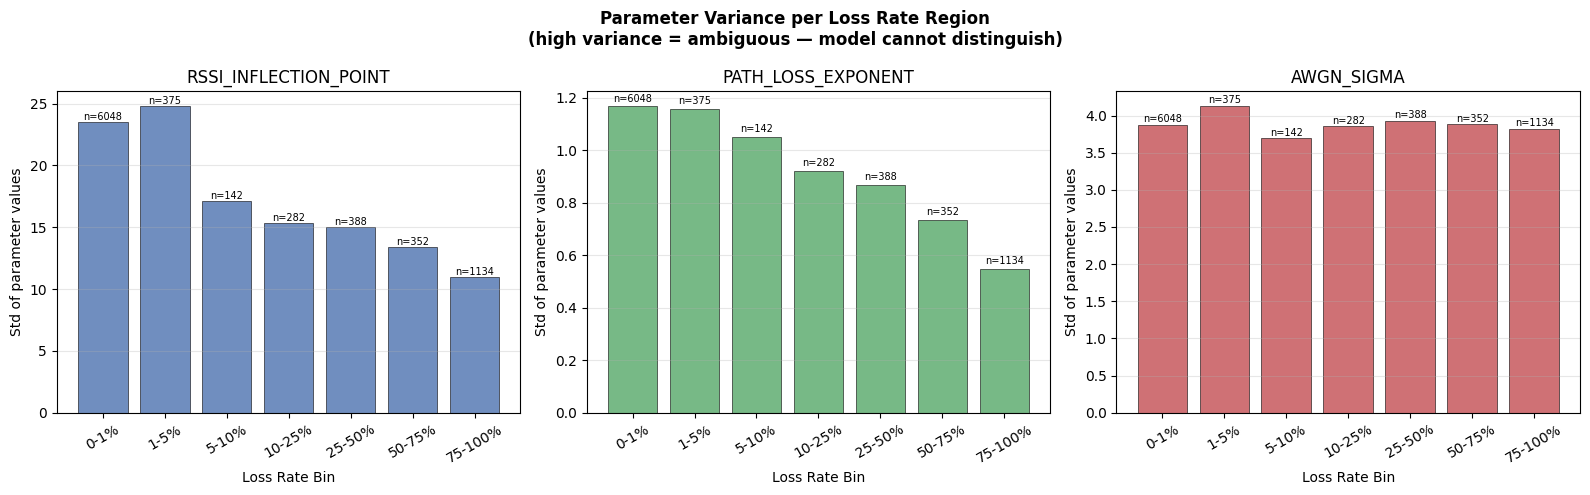


Parameter std per loss bin (high = ambiguous for model):

  RSSI_INFLECTION_POINT:
    0-1%      : std=23.524  n=6048
    1-5%      : std=24.783  n=375
    5-10%     : std=17.124  n=142
    10-25%    : std=15.321  n=282
    25-50%    : std=15.032  n=388
    50-75%    : std=13.400  n=352
    75-100%   : std=10.956  n=1134

  PATH_LOSS_EXPONENT:
    0-1%      : std=1.168  n=6048
    1-5%      : std=1.158  n=375
    5-10%     : std=1.051  n=142
    10-25%    : std=0.921  n=282
    25-50%    : std=0.868  n=388
    50-75%    : std=0.736  n=352
    75-100%   : std=0.549  n=1134

  AWGN_SIGMA:
    0-1%      : std=3.875  n=6048
    1-5%      : std=4.126  n=375
    5-10%     : std=3.695  n=142
    10-25%    : std=3.855  n=282
    25-50%    : std=3.925  n=388
    50-75%    : std=3.883  n=352
    75-100%   : std=3.817  n=1134


In [8]:
# Split into loss rate regions and check parameter variance in each
bins   = [0, 1, 5, 10, 25, 50, 75, 101]
labels = ['0-1%','1-5%','5-10%','10-25%','25-50%','50-75%','75-100%']
df['loss_bin'] = pd.cut(df['loss_rate_pct'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Parameter Variance per Loss Rate Region\n(high variance = ambiguous — model cannot distinguish)',
             fontsize=12, fontweight='bold')

for ax, param, color in zip(axes, PARAMS, ['#4C72B0','#55A868','#C44E52']):
    stds = df.groupby('loss_bin', observed=True)[param].std().reindex(labels)
    counts = df.groupby('loss_bin', observed=True)[param].count().reindex(labels)
    bars = ax.bar(labels, stds, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    # Annotate with row counts
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'n={cnt}', ha='center', va='bottom', fontsize=7)
    ax.set_title(param)
    ax.set_xlabel('Loss Rate Bin')
    ax.set_ylabel('Std of parameter values')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_identifiability.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nParameter std per loss bin (high = ambiguous for model):')
for param in PARAMS:
    print(f'\n  {param}:')
    for label in labels:
        subset = df[df['loss_bin'] == label]
        if len(subset) > 0:
            print(f'    {label:<10}: std={subset[param].std():.3f}  n={len(subset)}')

## 7. KPI Scatter vs Parameters
Visual check of how well each KPI separates parameter values.

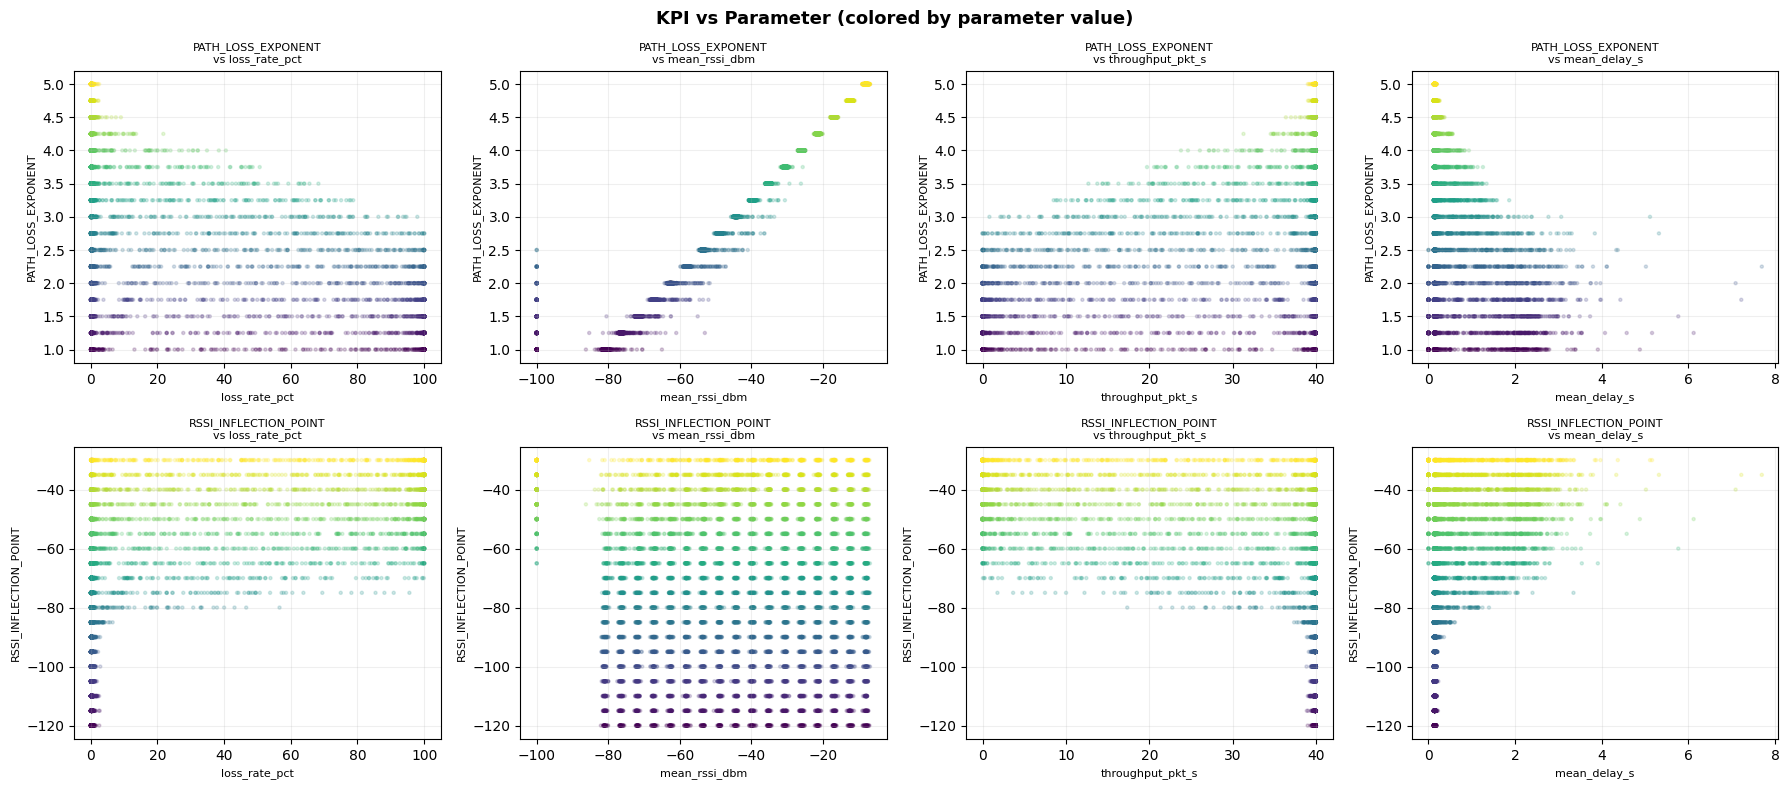

In [9]:
# Most informative KPIs vs most important parameters
plot_kpis   = ['loss_rate_pct', 'mean_rssi_dbm', 'throughput_pkt_s', 'mean_delay_s']
plot_params = ['PATH_LOSS_EXPONENT', 'RSSI_INFLECTION_POINT']

fig, axes = plt.subplots(len(plot_params), len(plot_kpis), figsize=(18, 8))
fig.suptitle('KPI vs Parameter (colored by parameter value)', fontsize=13, fontweight='bold')

for i, param in enumerate(plot_params):
    for j, kpi in enumerate(plot_kpis):
        ax = axes[i, j]
        sc = ax.scatter(df[kpi], df[param], alpha=0.2, s=5,
                        c=df[param], cmap='viridis')
        ax.set_xlabel(kpi, fontsize=8)
        ax.set_ylabel(param, fontsize=8)
        ax.set_title(f'{param}\nvs {kpi}', fontsize=8)
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Heatmap — Mean Loss Rate: Path Loss × RSSI Inflection

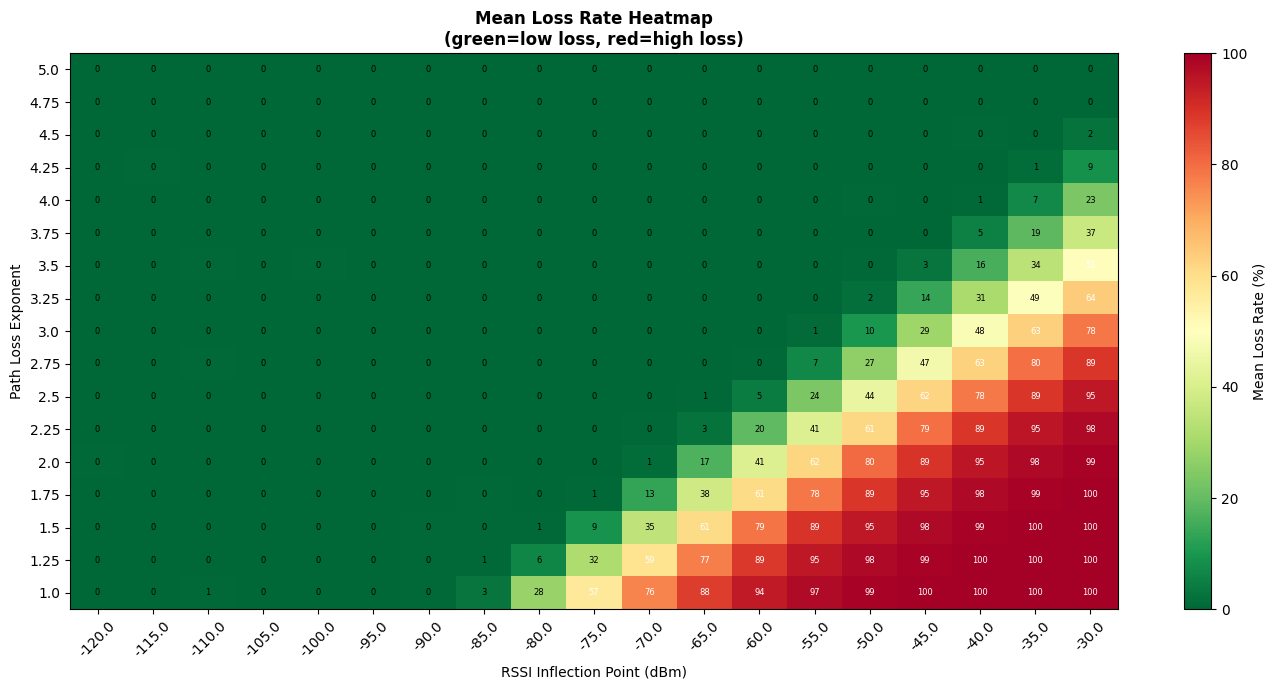

In [10]:
pivot = df.groupby(['PATH_LOSS_EXPONENT','RSSI_INFLECTION_POINT'])['loss_rate_pct'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100, origin='lower')
plt.colorbar(im, ax=ax, label='Mean Loss Rate (%)')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(v) for v in pivot.columns], rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(v) for v in pivot.index])
ax.set_xlabel('RSSI Inflection Point (dBm)')
ax.set_ylabel('Path Loss Exponent')
ax.set_title('Mean Loss Rate Heatmap\n(green=low loss, red=high loss)', fontweight='bold')

# Annotate each cell
for i in range(pivot.values.shape[0]):
    for j in range(pivot.values.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=6, color='white' if val > 50 else 'black')

plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Real KPI Coverage Check
Do your real FIT KPIs fall within the training distribution?

In [11]:
# ── PASTE YOUR REAL KPIs HERE ────────────────
real_kpis = {
    'mean_rssi_dbm':    -83.38,
    'std_rssi_dbm':      18.1062,
    'min_rssi_dbm':     -91.0,
    'loss_rate_pct':      47.82,
    'throughput_pkt_s':  28.14,
    'mean_delay_s':       0.778184,
    'std_delay_s':        1.03939,
    'std_loss_rate':      34.5207,
    'per_node_min_prr':   0.0,
}
# ─────────────────────────────────────────────

print(f'{"Feature":<25} {"Train Min":>10} {"Train Max":>10} {"Real Value":>12} {"In Range?":>10}')
print('-' * 70)
all_ok = True
for kpi in KPIS:
    tmin = df[kpi].min()
    tmax = df[kpi].max()
    val  = real_kpis.get(kpi, None)
    if val is None:
        continue
    ok = '✓' if tmin <= val <= tmax else '❌ OUT'
    if ok != '✓':
        all_ok = False
    print(f'{kpi:<25} {tmin:>10.4f} {tmax:>10.4f} {val:>12.4f} {ok:>10}')

print()
if all_ok:
    print('✓ All real KPIs are within training range — model should predict correctly')
else:
    print('❌ Some real KPIs are outside training range — model will extrapolate (unreliable)')

Feature                    Train Min  Train Max   Real Value  In Range?
----------------------------------------------------------------------
mean_rssi_dbm              -100.0000    -6.8100     -83.3800          ✓
std_rssi_dbm                  0.0000    18.9192      18.1062          ✓
min_rssi_dbm               -100.0000   -26.0000     -91.0000          ✓
loss_rate_pct                 0.0700   100.0000      47.8200          ✓
throughput_pkt_s              0.0000    39.9800      28.1400          ✓
mean_delay_s                  0.0000     7.6968       0.7782          ✓
std_delay_s                   0.0000     3.9460       1.0394          ✓
std_loss_rate                 0.0000    48.9087      34.5207          ✓
per_node_min_prr              0.0000     0.9987       0.0000          ✓

✓ All real KPIs are within training range — model should predict correctly


## 10. Dataset Balance Check
Are all parameter combinations equally represented, or is the dataset imbalanced?

Rows per parameter combination (should be roughly equal):
  Min combinations : 1
  Max combinations : 1
  Mean             : 1.0
  Std              : 0.0
  Total combos     : 8721



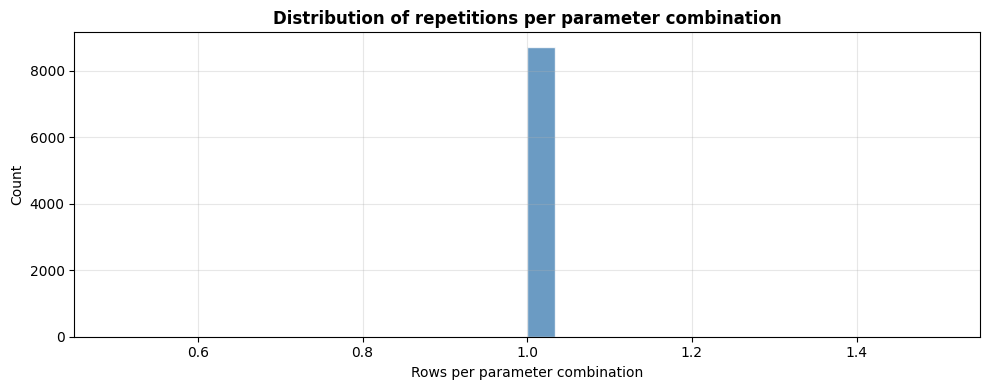

Expected combinations : 8721 (19 RSSI × 17 PLE × 27 AWGN)
Actual combinations   : 8721
Missing combinations  : 0


In [36]:
print('Rows per parameter combination (should be roughly equal):')
counts = df.groupby(PARAMS).size()
print(f'  Min combinations : {counts.min()}')
print(f'  Max combinations : {counts.max()}')
print(f'  Mean             : {counts.mean():.1f}')
print(f'  Std              : {counts.std():.1f}')
print(f'  Total combos     : {len(counts)}')
print()

# Repetitions per combo
fig, ax = plt.subplots(figsize=(10, 4))
counts.hist(bins=30, ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('Rows per parameter combination')
ax.set_ylabel('Count')
ax.set_title('Distribution of repetitions per parameter combination', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# Check if any combos are missing
all_rssi = sorted(df['RSSI_INFLECTION_POINT'].unique())
all_ple  = sorted(df['PATH_LOSS_EXPONENT'].unique())
all_awgn = sorted(df['AWGN_SIGMA'].unique())
expected = len(all_rssi) * len(all_ple) * len(all_awgn)
actual   = len(counts)
print(f'Expected combinations : {expected} ({len(all_rssi)} RSSI × {len(all_ple)} PLE × {len(all_awgn)} AWGN)')
print(f'Actual combinations   : {actual}')
print(f'Missing combinations  : {expected - actual}')

## 11. Summary & Recommendations

In [37]:
print('=' * 60)
print('  EDA SUMMARY')
print('=' * 60)
print(f'  Rows              : {len(df)}')
print(f'  Loss range        : {df["loss_rate_pct"].min():.2f}% → {df["loss_rate_pct"].max():.2f}%')
print(f'  Rows with loss<5% : {(df["loss_rate_pct"]<5).sum()} ({(df["loss_rate_pct"]<5).sum()/len(df)*100:.1f}%)')
print()

# Check if dataset is imbalanced toward high loss
pct_high = (df['loss_rate_pct'] > 50).sum() / len(df) * 100
pct_low  = (df['loss_rate_pct'] < 10).sum() / len(df) * 100

print(f'  Rows loss > 50%   : {pct_high:.1f}%')
print(f'  Rows loss < 10%   : {pct_low:.1f}%')
print()

if pct_high > pct_low * 3:
    print('  ⚠ Dataset is IMBALANCED — high loss scenarios dominate')
    print('  → Model will be biased toward predicting high-loss parameters')
    print('  → FIX: oversample low-loss rows or add more low-loss simulations')
elif pct_low > pct_high * 3:
    print('  ⚠ Dataset is IMBALANCED — low loss scenarios dominate')
else:
    print('  ✓ Dataset is reasonably balanced across loss rate range')

print()
print('  Strongest parameter→KPI correlations:')
for i, param in enumerate(PARAMS):
    for j, kpi in enumerate(KPIS):
        r, _ = stats.spearmanr(df[param], df[kpi])
        if abs(r) > 0.5:
            print(f'    {param} → {kpi}: r={r:+.3f}')

  EDA SUMMARY
  Rows              : 8721
  Loss range        : 0.07% → 100.00%
  Rows with loss<5% : 6423 (73.6%)

  Rows loss > 50%   : 17.0%
  Rows loss < 10%   : 75.3%

  ⚠ Dataset is IMBALANCED — low loss scenarios dominate

  Strongest parameter→KPI correlations:
    RSSI_INFLECTION_POINT → loss_rate_pct: r=+0.546
    RSSI_INFLECTION_POINT → throughput_pkt_s: r=-0.548
    RSSI_INFLECTION_POINT → per_node_min_prr: r=-0.547
    PATH_LOSS_EXPONENT → mean_rssi_dbm: r=+0.993
    PATH_LOSS_EXPONENT → std_rssi_dbm: r=+0.591
    PATH_LOSS_EXPONENT → min_rssi_dbm: r=+0.750
    AWGN_SIGMA → std_rssi_dbm: r=+0.760
    AWGN_SIGMA → min_rssi_dbm: r=-0.555
